# Sim 2: Manipulating Interference Density

> What intensifies interference from competing events — and which knob matters most?

In the selective interference paradigm, a participant encodes a set of *target* items (the "film list") and then, after a delay, processes a set of *competitor* items before free recall. The central question is what determines how much those competitors suppress recall of the targets. Three candidate intensifiers arise from the structure of context-based memory models:

1. **Encoding strength** — how strongly competitors are bound into the context-to-item association matrix (M\_CF). Stronger associations mean higher retrieval support for competitors, which diverts probability mass away from film items during the competitive recall process.

2. **Context proximity** — how much temporal context drifts during the interference phase. If drift is low, competitors are encoded in a context state that overlaps heavily with the film items, making them strong competitors at retrieval. High drift pushes competitors into a distant region of context space, attenuating their competitive effect.

3. **Competitor count** — the sheer number of interfering items. More competitors mean more total competition, but with a caveat: later competitors accumulate more contextual drift from the film region, so each additional competitor should produce diminishing returns.

This notebook sweeps each intensifier in isolation while holding the others fixed, establishing which manipulations produce interference and how strong the effects are. The findings inform all subsequent simulations: they determine the parameter values we carry forward when modeling more complex phenomena like selective rehearsal and cue-driven reactivation.

The trial sequence mirrors the experimental procedure. A CMR model first encodes 16 film items using parameters fitted to individual subjects from the Healey & Kahana (2014) free-recall dataset. A long delay is simulated by hard-resetting temporal context to start-of-list state, discarding all encoding-phase drift. A *reminder* phase then reinstates film context: each film item's associated context is retrieved via M\_FC and integrated into the current state without updating any association matrices. This places the model in a context state that resembles the end of film encoding — the theoretical basis for why interference items, encoded next, become bound to film-like context and compete at retrieval. After the reminder, the model's drift rate and MCF learning rate are swapped to interference-phase values and competitor items are encoded (16 by default, up to 32 in the count sweep). Following interference, *filler* items are encoded to simulate everyday events between the interference task and the recall test; these naturally suppress recency for interference items so that any observed competition arises from shared context (the theorized mechanism) rather than temporal proximity. Finally, `start_retrieving()` blends start-of-list context into the current state at the subject's fitted `start_drift_rate`, providing a graded reinstatement mechanism before free recall begins via context-cued competition with a Luce choice rule. Filler parameters are held constant across all sweeps, so they shift the baseline uniformly without affecting relative comparisons between conditions.

## Table of contents

- [Setup](#setup)
- [Fitting per-subject parameters](#fitting-per-subject-parameters)
  - [Parameter summary](#parameter-summary)
- [Building the trial function](#building-the-trial-function)
- [Baseline SPC](#baseline-spc)
- [Sweeping reminder drift scale](#sweeping-reminder-drift-scale)
- [Sweeping MCF learning rate](#sweeping-mcf-learning-rate)
- [Sweeping interference encoding drift rate](#sweeping-interference-encoding-drift-rate)
- [Sweeping competitor count](#sweeping-competitor-count)
- [Summary and parameters for subsequent simulations](#summary-and-parameters-for-subsequent-simulations)

## Setup

In [1]:
import json
import warnings
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax import jit, lax, random, vmap
from jax.tree_util import tree_map
from typing import Optional

from jaxcmr.analyses.spc import fixed_pres_spc
from jaxcmr.components.context import init as init_context
from jaxcmr.components.linear_memory import init_mcf, init_mfc
from jaxcmr.components.termination import PositionalTermination
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.models.cmr import CMR, make_factory
from jaxcmr.selective_interference.plotting import (
    plot_interference_spc,
    plot_summary_dv,
)
from jaxcmr.simulation import simulate_free_recall

warnings.filterwarnings("ignore")

In [2]:
# --- paradigm constants ---
N_FILM = 16
M_DEFAULT = 16
M_MAX = 32
N_FILLER = 0
LIST_LENGTH = N_FILM + M_MAX + N_FILLER  # 64
EXPERIMENT_COUNT = 100
FILM_RECALLED_YLIM: Optional[list[float]] = None  # tuple to fix y-axis, None to auto-scale

# --- default scale factors for non-swept phases ---
DEFAULT_REMINDER_DRIFT_SCALE = 1.0
DEFAULT_FILLER_DRIFT_SCALE = 1.0
DEFAULT_FILLER_MCF_SCALE = 1.0

# --- fitting ---
SEED = 0
DATA_TAG = "HealeyKahana2014"
DATA_PATH = "data/HealeyKahana2014.h5"
TRIAL_QUERY = "data['listtype'] == -1"
MODEL_NAME = "WeirdCMRPosStop"
BEST_OF = 1
RUN_TAG = f"best_of_{BEST_OF}"
REDO_FITS = False

# --- paths ---
project_root = Path(find_project_root())
fit_dir = Path("results/fits")
fit_dir.mkdir(parents=True, exist_ok=True)
fit_path = fit_dir / f"{DATA_TAG}_{MODEL_NAME}_{RUN_TAG}.json"

# --- data ---
data = load_data(str(project_root / DATA_PATH))
trial_mask = generate_trial_mask(data, TRIAL_QUERY)

# --- model factory (for fitting only) ---
model_factory = make_factory(init_mfc, init_mcf, init_context, PositionalTermination)

rng = random.PRNGKey(SEED)

## Fitting per-subject parameters

We fit CMR to each subject's free-recall data from Healey & Kahana (2014) — a 16-item word-list experiment that maps directly onto our 16-item film list. The model variant uses `PositionalTermination`: stop probability grows exponentially with the number of items already recalled (`scale * exp(position * growth)`), giving the model a realistic tendency to terminate recall before exhausting the pool. The loss function (`MemorySearchLikelihoodFnGenerator`) evaluates the full recall sequence including the termination event, so the optimizer jointly fits recall order and stopping behaviour.

Eleven free parameters are fitted per subject: `encoding_drift_rate`, `start_drift_rate`, `recall_drift_rate`, `shared_support`, `item_support`, `learning_rate` (MFC), `primacy_scale`, `primacy_decay`, `choice_sensitivity`, `stop_probability_scale`, and `stop_probability_growth`. Differential evolution (`ScipyDE`) runs 1000 generations with a population of 15 and takes the best of 3 independent runs.

Fitted parameters are cached to disk. On subsequent runs, the fitting cell loads from cache unless `REDO_FITS` is set to `True`.

In [3]:
if fit_path.exists() and not REDO_FITS:
    with fit_path.open() as f:
        results = json.load(f)
    print(f"Loaded fits from {fit_path}")
else:
    from jaxcmr.fitting import ScipyDE
    from jaxcmr.loss.sequence_likelihood import MemorySearchLikelihoodFnGenerator

    fixed = {
        "allow_repeated_recalls": False,
        "learn_after_context_update": False,
    }
    free_bounds = {
        "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "shared_support": [2.220446049250313e-16, 99.9999999999999998],
        "item_support": [2.220446049250313e-16, 99.9999999999999998],
        "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
        "primacy_scale": [2.220446049250313e-16, 99.9999999999999998],
        "primacy_decay": [2.220446049250313e-16, 99.9999999999999998],
        "choice_sensitivity": [2.220446049250313e-16, 99.9999999999999998],
        "stop_probability_scale": [2.22e-16, 5.0],
        "stop_probability_growth": [2.22e-16, 10.0],
    }
    fitter = ScipyDE(
        data,
        None,
        fixed,
        model_factory,
        MemorySearchLikelihoodFnGenerator,
        hyperparams={
            "bounds": free_bounds,
            "num_steps": 200,
            "pop_size": 15,
            "relative_tolerance": 0.001,
            "cross_over_rate": 0.9,
            "diff_w": 0.85,
            "best_of": BEST_OF,
            "progress_bar": True,
        },
    )
    results = fitter.fit(trial_mask)
    with fit_path.open("w") as f:
        json.dump(results, f, indent=4)
    print(f"Fitted and saved to {fit_path}")

params = {key: jnp.array(val) for key, val in results["fits"].items()}
n_subjects = len(params["encoding_drift_rate"])
median_idx = n_subjects // 2
print(f"{n_subjects} subjects")

Loaded fits from results/fits/HealeyKahana2014_WeirdCMRPosStop_best_of_1.json
126 subjects


### Parameter summary

The table below shows the distribution of fitted values across subjects. These are the parameters that govern film-phase encoding — the interference phase will use different values for `encoding_drift_rate` and the MCF learning rate, while leaving everything else at the fitted values.

In [4]:
free_params = [
    "encoding_drift_rate",
    "start_drift_rate",
    "recall_drift_rate",
    "shared_support",
    "item_support",
    "learning_rate",
    "primacy_scale",
    "primacy_decay",
    "choice_sensitivity",
    "stop_probability_scale",
    "stop_probability_growth",
]

print(f"{'Parameter':>25s}  {'Mean':>8s}  {'Std':>8s}  {'Min':>8s}  {'Max':>8s}")
print("-" * 65)
for name in free_params:
    vals = np.array(params[name])
    print(
        f"{name:>25s}  {vals.mean():8.4f}  {vals.std():8.4f}  {vals.min():8.4f}  {vals.max():8.4f}"
    )

                Parameter      Mean       Std       Min       Max
-----------------------------------------------------------------
      encoding_drift_rate    0.7702    0.1475    0.0294    0.9833
         start_drift_rate    0.2017    0.2199    0.0012    0.9362
        recall_drift_rate    0.8476    0.1150    0.4489    0.9976
           shared_support   19.5325   22.7464    0.0880   99.9017
             item_support   30.2362   29.0810    0.2694   99.8182
            learning_rate    0.2960    0.2288    0.0075    0.9637
            primacy_scale   17.7227   23.6121    0.2289   98.5164
            primacy_decay   23.5531   30.8395    0.0001   92.6645
       choice_sensitivity   46.9343   32.8021    1.2412   99.9499
   stop_probability_scale    0.0080    0.0100    0.0000    0.0584
  stop_probability_growth    0.3721    0.0902    0.1142    0.6394


## Building the trial function

Each sweep will run hundreds of simulated trials — one per subject per replication — so we need a function that takes a subject's fitted parameters, creates a fresh CMR, and executes the full paradigm. The key design constraint comes from JAX: to vectorize across subjects with `vmap`, every array must have the same shape regardless of how many competitors we present. We solve this by always allocating 32 interference slots and zero-padding unused positions. CMR's `experience(0)` is a no-op, so zero-padded items are silently skipped during encoding without affecting the model state.

The trial function implements a five-phase sequence:

1. **Film encoding** — 16 items encoded with the subject's fitted parameters.
2. **Delay** — temporal context is hard-reset to start-of-list state, simulating the long interval between film viewing and the interference task.
3. **Reminder** — each film item's associated context is retrieved via M\_FC and integrated into the current state at `reminder_drift_scale × encoding_drift_rate`, *without* updating any association matrices. This reinstates film-like context so that interference items will be encoded in a context state that overlaps with the film region.
4. **Interference + fillers** — the drift rate and MCF learning rate are swapped to interference-phase values (scale factors over the fitted parameters), competitors are encoded, then the drift rate is swapped again for filler items that simulate everyday events between the interference task and recall. The MCF learning rate uses a three-zone array: film positions retain the fitted primacy gradient, interference positions are scaled by `interference_mcf_scale`, and filler positions are scaled by `filler_mcf_scale`.
5. **Recall** — `start_retrieving()` blends start-of-list context into the current state at the subject's fitted `start_drift_rate`, then free recall proceeds via context-cued competition.

We wrap this in a `vmap` over subjects and replications, giving us a single `batched_trial` call that returns all recall sequences for a given sweep value.

In [5]:
FILM_ITEMS = jnp.arange(1, N_FILM + 1)
ALL_INTERFERENCE_ITEMS = jnp.arange(N_FILM + 1, N_FILM + M_MAX + 1)
FILLER_ITEMS = jnp.arange(N_FILM + M_MAX + 1, LIST_LENGTH + 1)


def simulate_film_and_interference_trial(
    model, film_items, interference_items, filler_items,
    interference_drift_scale, interference_mcf_scale,
    reminder_drift_scale,
    filler_drift_scale, filler_mcf_scale,
    rng,
):
    """Encode film, remind, encode interference + fillers, then recall."""
    original_drift = model.encoding_drift_rate

    # --- film phase (fitted parameters) ---
    model = lax.fori_loop(
        0, film_items.size, lambda i, m: m.experience(film_items[i]), model
    )

    # --- delay: hard reset context to start-of-list state ---
    model = model.replace(
        context=model.context.replace(state=model.context.initial_state)
    )

    # --- reminder: reinstate film context without new learning ---
    reminder_drift = jnp.clip(
        reminder_drift_scale * original_drift, 0.0, 1.0
    )

    def reminder_step(i, m):
        item = m.items[film_items[i] - 1]
        context_input = m.mfc.probe(item)
        new_context = m.context.integrate(context_input, reminder_drift)
        return m.replace(context=new_context)

    model = lax.fori_loop(0, film_items.size, reminder_step, model)

    # --- parameter swap: three-zone MCF learning rate ---
    n_film = film_items.shape[0]
    n_interf = interference_items.shape[0]
    n_filler = filler_items.shape[0]
    list_length = n_film + n_interf + n_filler
    pos = jnp.arange(list_length)
    is_film = pos < n_film
    is_interf = (pos >= n_film) & (pos < n_film + n_interf)
    phase_mcf_lr = jnp.where(
        is_film,
        model._mcf_learning_rate,
        jnp.where(
            is_interf,
            interference_mcf_scale * model._mcf_learning_rate,
            filler_mcf_scale * model._mcf_learning_rate,
        ),
    )
    interference_drift = jnp.clip(
        interference_drift_scale * original_drift, 0.0, 1.0
    )
    model = model.replace(
        encoding_drift_rate=interference_drift,
        _mcf_learning_rate=phase_mcf_lr,
    )

    # --- interference phase (zero-padded items) ---
    model = lax.fori_loop(
        0,
        interference_items.size,
        lambda i, m: m.experience(interference_items[i]),
        model,
    )

    # --- filler phase (skipped when N_FILLER = 0) ---
    if n_filler > 0:
        filler_drift = jnp.clip(filler_drift_scale * original_drift, 0.0, 1.0)
        model = model.replace(encoding_drift_rate=filler_drift)
        model = lax.fori_loop(
            0,
            filler_items.size,
            lambda i, m: m.experience(filler_items[i]),
            model,
        )

    # --- recall: start_retrieving() blends start context at fitted rate ---
    model = model.start_retrieving()
    return simulate_free_recall(model, list_length, rng)


def _create_and_run_trial(
    subject_idx,
    rng,
    params,
    film_items,
    interference_items,
    filler_items,
    interference_drift_scale,
    interference_mcf_scale,
    reminder_drift_scale,
    filler_drift_scale,
    filler_mcf_scale,
):
    """Create a per-subject CMR and run one film+interference trial."""
    subject_params = tree_map(lambda p: p[subject_idx], params)
    model = CMR(
        LIST_LENGTH,
        subject_params,
        mfc_create_fn=init_mfc,
        mcf_create_fn=init_mcf,
        context_create_fn=init_context,
        termination_policy_create_fn=PositionalTermination,
    )
    _, recalls = simulate_film_and_interference_trial(
        model,
        film_items,
        interference_items,
        filler_items,
        interference_drift_scale,
        interference_mcf_scale,
        reminder_drift_scale,
        filler_drift_scale,
        filler_mcf_scale,
        rng,
    )
    return recalls


batched_trial = jit(
    vmap(
        _create_and_run_trial,
        in_axes=(0, 0, None, None, None, None, None, None, None, None, None),
    )
)


def film_recalled_stats(recalls):
    """Mean and 95% CI of film items recalled (per-subject aggregation)."""
    film_mask = (recalls >= 1) & (recalls <= N_FILM)
    per_trial = jnp.sum(film_mask, axis=1).astype(float)
    per_sub = per_trial.reshape(n_subjects, EXPERIMENT_COUNT)
    sub_means = jnp.mean(per_sub, axis=1)
    mu = float(jnp.mean(sub_means))
    se = float(jnp.std(sub_means) / jnp.sqrt(n_subjects))
    return mu, mu - 1.96 * se, mu + 1.96 * se


def make_interference_items(m):
    """1-indexed interference items, zero-padded to M_MAX."""
    return jnp.where(jnp.arange(M_MAX) < m, ALL_INTERFERENCE_ITEMS, 0)


DEFAULT_INTERFERENCE_ITEMS = make_interference_items(M_DEFAULT)


def trial_indices_and_rngs(rng):
    """Subject indices and per-trial RNGs for one sweep value."""
    total = n_subjects * EXPERIMENT_COUNT
    sub_idx = jnp.repeat(jnp.arange(n_subjects), EXPERIMENT_COUNT)
    rng, sub_rng = random.split(rng)
    rngs = random.split(sub_rng, total)
    return sub_idx, rngs, rng

## Baseline SPC

Before sweeping the encoding-phase intensifiers, we set a reference condition. All 16 competitors are present with MCF scale = 1.0 — each interference item's MCF learning rate equals what it would receive as an ordinary study item at that position in the primacy gradient. This provides a baseline SPC against which the MCF, drift, and count sweeps can be compared.

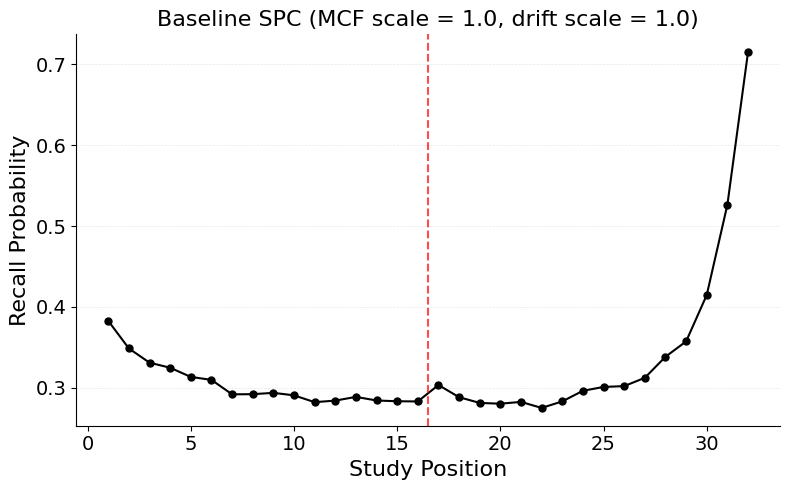

Film items recalled: 4.89 [4.59, 5.18]


In [6]:
BASELINE_MCF_SCALE = 1.0
DEFAULT_PRESENTED = N_FILM + M_DEFAULT + N_FILLER  # positions actually used when M = M_DEFAULT

sub_idx, rngs, rng = trial_indices_and_rngs(rng)
baseline_recalls = batched_trial(
    sub_idx,
    rngs,
    params,
    FILM_ITEMS,
    DEFAULT_INTERFERENCE_ITEMS,
    FILLER_ITEMS,
    jnp.float32(1.0),
    jnp.float32(BASELINE_MCF_SCALE),
    jnp.float32(DEFAULT_REMINDER_DRIFT_SCALE),
    jnp.float32(DEFAULT_FILLER_DRIFT_SCALE),
    jnp.float32(DEFAULT_FILLER_MCF_SCALE),
)
baseline_spc = fixed_pres_spc(baseline_recalls, DEFAULT_PRESENTED)
baseline_stats = film_recalled_stats(baseline_recalls)

fig, ax = plt.subplots(figsize=(8, 5))
positions = np.arange(1, DEFAULT_PRESENTED + 1)
ax.plot(
    positions,
    np.asarray(baseline_spc),
    "o-",
    color="black",
    markersize=5,
    linewidth=1.5,
)
ax.axvline(x=N_FILM + 0.5, color="red", linestyle="--", alpha=0.7)
ax.set_xlabel("Study Position", fontsize=16)
ax.set_ylabel("Recall Probability", fontsize=16)
ax.set_title(f"Baseline SPC (MCF scale = {BASELINE_MCF_SCALE}, drift scale = 1.0)", fontsize=16)
ax.tick_params(labelsize=14)
for loc in ("top", "right"):
    ax.spines[loc].set_visible(False)
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.3)
fig.tight_layout()
plt.show()

mu, lo, hi = baseline_stats
print(f"Film items recalled: {mu:.2f} [{lo:.2f}, {hi:.2f}]")

## Sweeping reminder drift scale

Before the interference task begins, participants view a brief reminder of the film. In the model, this is implemented as a context-reinstatement loop: after the hard reset (simulating the long delay since original viewing), each film item's associated context is retrieved via M\_FC and integrated into the current state — without updating any association matrices. The `reminder_drift_scale` is a scale factor applied to each subject's fitted `encoding_drift_rate`, controlling how strongly this reinstatement occurs relative to the original encoding.

At low scales, context barely moves from the reset state (minimal reinstatement — as if the reminder were ineffective). At high scales, context drifts rapidly through the film sequence, arriving at a state dominated by the last few film items. Because interference items are subsequently encoded in this reinstated context, the reminder drift scale controls how much contextual overlap exists between film and interference items — and therefore how strongly they compete at retrieval.

MCF scale = 1.0, interference drift scale = 1.0, competitor count = 16, filler parameters at defaults.

In [7]:
reminder_scale_values = np.linspace(0.01, 1.8, 10)
print(f"Reminder drift scale sweep values: {reminder_scale_values.round(3)}")

sweep_rem_spcs = []
sweep_rem_stats = []

for rs in reminder_scale_values:
    sub_idx, rngs, rng = trial_indices_and_rngs(rng)
    recalls = batched_trial(
        sub_idx,
        rngs,
        params,
        FILM_ITEMS,
        DEFAULT_INTERFERENCE_ITEMS,
        FILLER_ITEMS,
        jnp.float32(1.0),
        jnp.float32(1.0),
        jnp.float32(rs),
        jnp.float32(DEFAULT_FILLER_DRIFT_SCALE),
        jnp.float32(DEFAULT_FILLER_MCF_SCALE),
    )
    sweep_rem_spcs.append(fixed_pres_spc(recalls, DEFAULT_PRESENTED))
    sweep_rem_stats.append(film_recalled_stats(recalls))

print("Reminder sweep done")

Reminder drift scale sweep values: [0.01  0.209 0.408 0.607 0.806 1.004 1.203 1.402 1.601 1.8  ]
Reminder sweep done


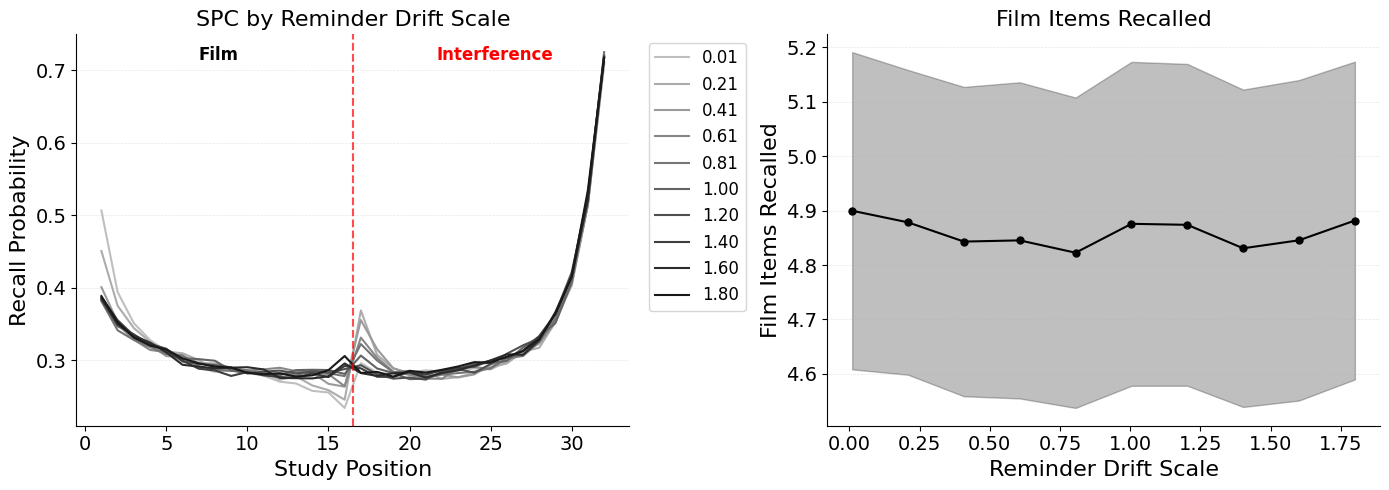

In [8]:
labels = [f"{v:.2f}" for v in reminder_scale_values]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_interference_spc(sweep_rem_spcs, labels, N_FILM, ax=axes[0])
axes[0].set_title("SPC by Reminder Drift Scale", fontsize=16)

means, ci_lo, ci_hi = zip(*sweep_rem_stats)
plot_summary_dv(
    reminder_scale_values,
    means,
    ci_lo,
    ci_hi,
    xlabel="Reminder Drift Scale",
    ax=axes[1],
)
axes[1].set_title("Film Items Recalled", fontsize=16)
if FILM_RECALLED_YLIM is not None:
    axes[1].set_ylim(*FILM_RECALLED_YLIM)

plt.tight_layout()
plt.show()

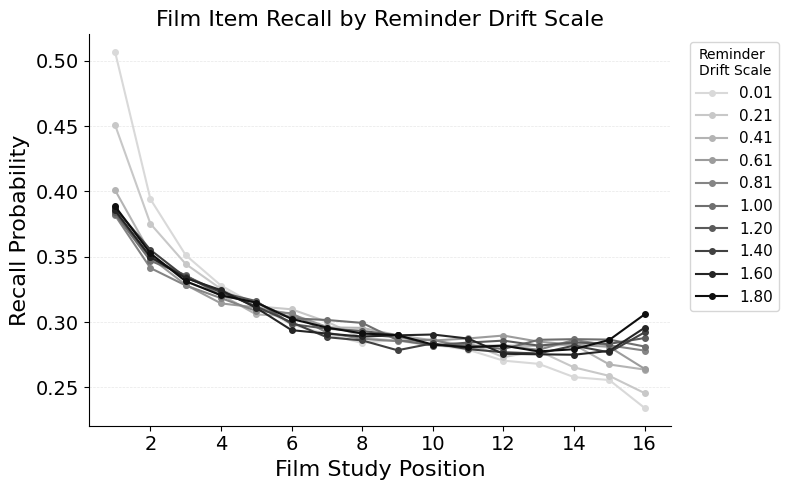

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
positions = np.arange(1, N_FILM + 1)
colors = plt.colormaps["Greys"](np.linspace(0.25, 0.95, len(reminder_scale_values)))

for spc, rs, color in zip(sweep_rem_spcs, reminder_scale_values, colors):
    ax.plot(positions, np.asarray(spc)[:N_FILM], "o-", color=color,
            label=f"{rs:.2f}", markersize=4, linewidth=1.5)

ax.set_xlabel("Film Study Position", fontsize=16)
ax.set_ylabel("Recall Probability", fontsize=16)
ax.set_title("Film Item Recall by Reminder Drift Scale", fontsize=16)
ax.tick_params(labelsize=14)
for loc in ("top", "right"):
    ax.spines[loc].set_visible(False)
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.3)
ax.legend(title="Reminder\nDrift Scale", loc="upper left",
          bbox_to_anchor=(1.02, 1), fontsize=11)
fig.tight_layout()
plt.show()

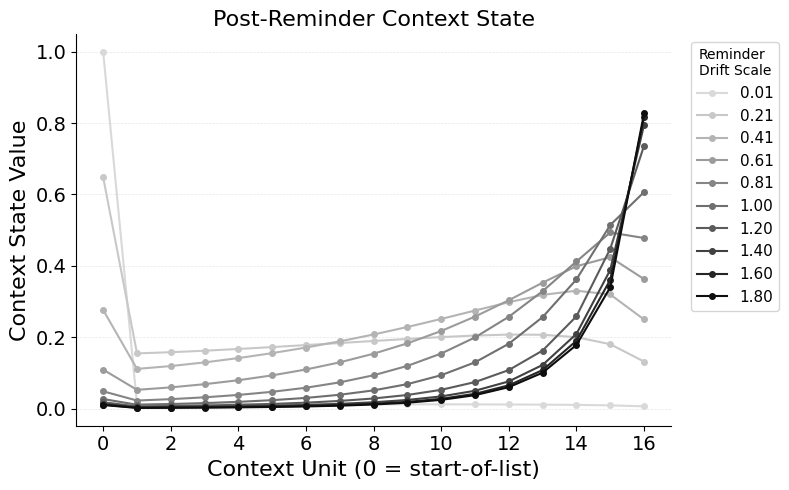

In [10]:
def get_post_reminder_context(subject_idx, params, film_items, reminder_drift_scale):
    """Context state values at film-item units after reminder phase."""
    subject_params = tree_map(lambda p: p[subject_idx], params)
    model = CMR(
        LIST_LENGTH,
        subject_params,
        mfc_create_fn=init_mfc,
        mcf_create_fn=init_mcf,
        context_create_fn=init_context,
        termination_policy_create_fn=PositionalTermination,
    )
    original_drift = model.encoding_drift_rate

    # film phase
    model = lax.fori_loop(
        0, film_items.size, lambda i, m: m.experience(film_items[i]), model
    )

    # hard reset
    model = model.replace(
        context=model.context.replace(state=model.context.initial_state)
    )

    # reminder
    reminder_drift = jnp.clip(reminder_drift_scale * original_drift, 0.0, 1.0)

    def reminder_step(i, m):
        item = m.items[film_items[i] - 1]
        context_input = m.mfc.probe(item)
        new_context = m.context.integrate(context_input, reminder_drift)
        return m.replace(context=new_context)

    model = lax.fori_loop(0, film_items.size, reminder_step, model)

    # return context units for film items (indices 1..N_FILM) and start-of-list (index 0)
    return model.context.state[:N_FILM + 1]


_batched_context = jit(
    vmap(get_post_reminder_context, in_axes=(0, None, None, None))
)
sub_indices = jnp.arange(n_subjects)

fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.colormaps["Greys"](np.linspace(0.25, 0.95, len(reminder_scale_values)))

for rs, color in zip(reminder_scale_values, colors):
    ctx = _batched_context(sub_indices, params, FILM_ITEMS, jnp.float32(rs))
    mean_ctx = np.asarray(jnp.mean(ctx, axis=0))
    # index 0 = start-of-list, indices 1..N_FILM = film items
    positions = np.arange(0, N_FILM + 1)
    ax.plot(positions, mean_ctx, "o-", color=color, label=f"{rs:.2f}",
            markersize=4, linewidth=1.5)

ax.set_xlabel("Context Unit (0 = start-of-list)", fontsize=16)
ax.set_ylabel("Context State Value", fontsize=16)
ax.set_title("Post-Reminder Context State", fontsize=16)
ax.tick_params(labelsize=14)
for loc in ("top", "right"):
    ax.spines[loc].set_visible(False)
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.3)
ax.legend(title="Reminder\nDrift Scale", loc="upper left",
          bbox_to_anchor=(1.02, 1), fontsize=11)
fig.tight_layout()
plt.show()

The film-item SPC reveals what the reminder drift scale actually does to context before interference begins. At low scales, context stays near start-of-list state — recall is concentrated at position 1 with little support for later items. At high scales, context drifts through the full film sequence and arrives at a state resembling end-of-film context, producing a recency-weighted recall profile across film positions. Intermediate scales yield a mix.

Despite these differences in context state, the total number of film items recalled is flat across the sweep. The reminder redistributes *which* film items are recalled but does not change *how many*. Without filler events to suppress recency, the strong recency advantage for interference items (visible in the SPC spike at late positions) dominates the competitive dynamics regardless of how much film context is reinstated.

## Sweeping MCF learning rate

The first encoding-phase intensifier is encoding strength in the context-to-item association matrix (M\_CF). During film encoding, the MCF learning rate follows the fitted primacy gradient — high at position 1, decaying toward 1.0 by position 16. During the interference phase, each competitor's MCF learning rate is a scale factor times what the primacy gradient would assign at that position. At scale = 1.0, interference items are encoded exactly as if they were additional study items; at scale = 0, they receive no M\_CF encoding; at scale > 1, they are encoded more strongly than normal.

The sweep ranges from 0 to 4.0 in 10 steps. Each subject uses their own fitted `encoding_drift_rate` during the interference phase, keeping context proximity constant across the sweep.

In [11]:
mcf_scale_values = np.linspace(0, 4, 10)
print(f"MCF scale sweep values: {mcf_scale_values.round(2)}")

sweep1_spcs = []
sweep1_stats = []

for scale_val in mcf_scale_values:
    sub_idx, rngs, rng = trial_indices_and_rngs(rng)
    recalls = batched_trial(
        sub_idx,
        rngs,
        params,
        FILM_ITEMS,
        DEFAULT_INTERFERENCE_ITEMS,
        FILLER_ITEMS,
        jnp.float32(1.0),
        jnp.float32(scale_val),
        jnp.float32(DEFAULT_REMINDER_DRIFT_SCALE),
        jnp.float32(DEFAULT_FILLER_DRIFT_SCALE),
        jnp.float32(DEFAULT_FILLER_MCF_SCALE),
    )
    sweep1_spcs.append(fixed_pres_spc(recalls, DEFAULT_PRESENTED))
    sweep1_stats.append(film_recalled_stats(recalls))

print("Sweep 1 done")

MCF scale sweep values: [0.   0.44 0.89 1.33 1.78 2.22 2.67 3.11 3.56 4.  ]
Sweep 1 done


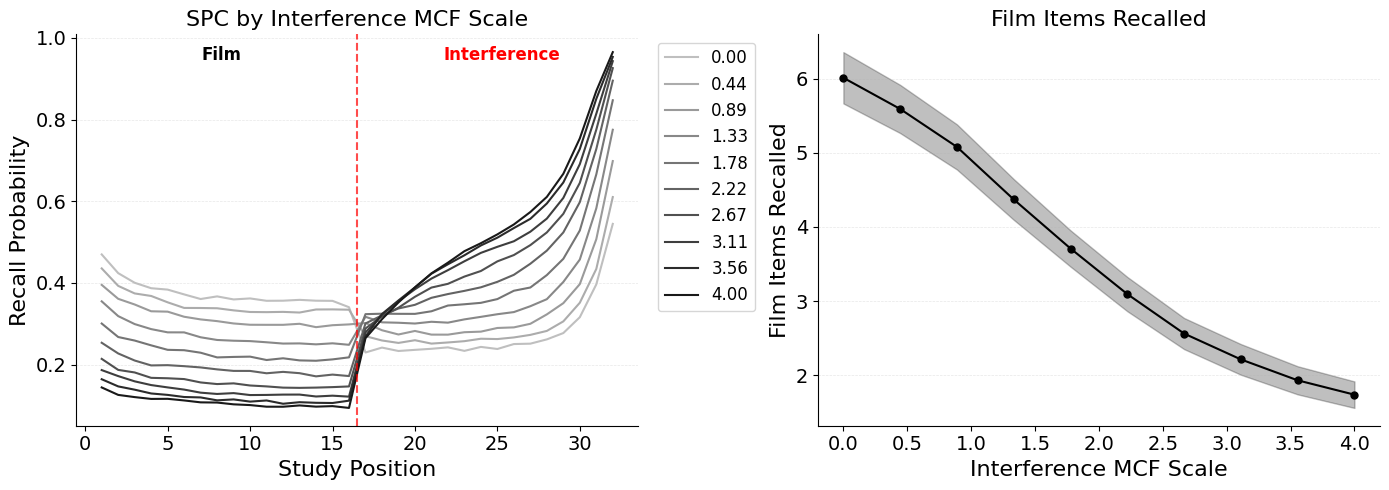

In [12]:
labels = [f"{v:.2f}" for v in mcf_scale_values]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_interference_spc(sweep1_spcs, labels, N_FILM, ax=axes[0])
axes[0].set_title("SPC by Interference MCF Scale", fontsize=16)

means, ci_lo, ci_hi = zip(*sweep1_stats)
plot_summary_dv(
    mcf_scale_values,
    means,
    ci_lo,
    ci_hi,
    xlabel="Interference MCF Scale",
    ax=axes[1],
)
axes[1].set_title("Film Items Recalled", fontsize=16)
if FILM_RECALLED_YLIM is not None:
    axes[1].set_ylim(*FILM_RECALLED_YLIM)

plt.tight_layout()
plt.show()

The left panel shows how the serial position curve changes as MCF scale increases. At scale = 0, competitors receive no encoding and are never recalled — the SPC matches the film-only baseline. As the scale grows, interference items accumulate retrieval support and the Luce choice rule redistributes recall probability away from film items, particularly those at late study positions whose recency advantage is directly contested.

The right panel condenses this into a single dependent variable: mean film items recalled with 95% CI. The monotonic decrease confirms that stronger M\_CF encoding of competitors produces more interference — the first of our three intensifiers.

## Sweeping interference encoding drift rate

The second intensifier is context proximity between film items and competitors. The `encoding_drift_rate` parameter controls how much temporal context updates when each item is encoded. During the film phase, this is the subject's fitted value. During interference, we scale it by a factor: at scale = 1.0 context drifts at the same rate as during film encoding; at scale < 1.0 drift is slower (competitors stay closer to film context); at scale > 1.0 drift is faster (competitors are pushed further away). The product is clipped to [0, 1].

Low drift during interference keeps competitors' context representations close to the end-of-film context state. High drift pushes competitors into a distant region of context space where they are poor matches for the retrieval probe.

We expect a dose-response curve: low scales produce maximal interference, and increasing scale progressively reduces it, approaching a ceiling where competitors are so contextually distant they barely compete. We fix the MCF scale at 1.0 and sweep drift scale from 0.2 to 1.8.

In [13]:
drift_scale_values = np.linspace(0.2, 1.8, 10)
print(f"Drift scale sweep values: {drift_scale_values.round(2)}")

sweep2_spcs = []
sweep2_stats = []

for ds in drift_scale_values:
    sub_idx, rngs, rng = trial_indices_and_rngs(rng)
    recalls = batched_trial(
        sub_idx,
        rngs,
        params,
        FILM_ITEMS,
        DEFAULT_INTERFERENCE_ITEMS,
        FILLER_ITEMS,
        jnp.float32(ds),
        jnp.float32(1.0),
        jnp.float32(DEFAULT_REMINDER_DRIFT_SCALE),
        jnp.float32(DEFAULT_FILLER_DRIFT_SCALE),
        jnp.float32(DEFAULT_FILLER_MCF_SCALE),
    )
    sweep2_spcs.append(fixed_pres_spc(recalls, DEFAULT_PRESENTED))
    sweep2_stats.append(film_recalled_stats(recalls))

print("Sweep 2 done")

Drift scale sweep values: [0.2  0.38 0.56 0.73 0.91 1.09 1.27 1.44 1.62 1.8 ]
Sweep 2 done


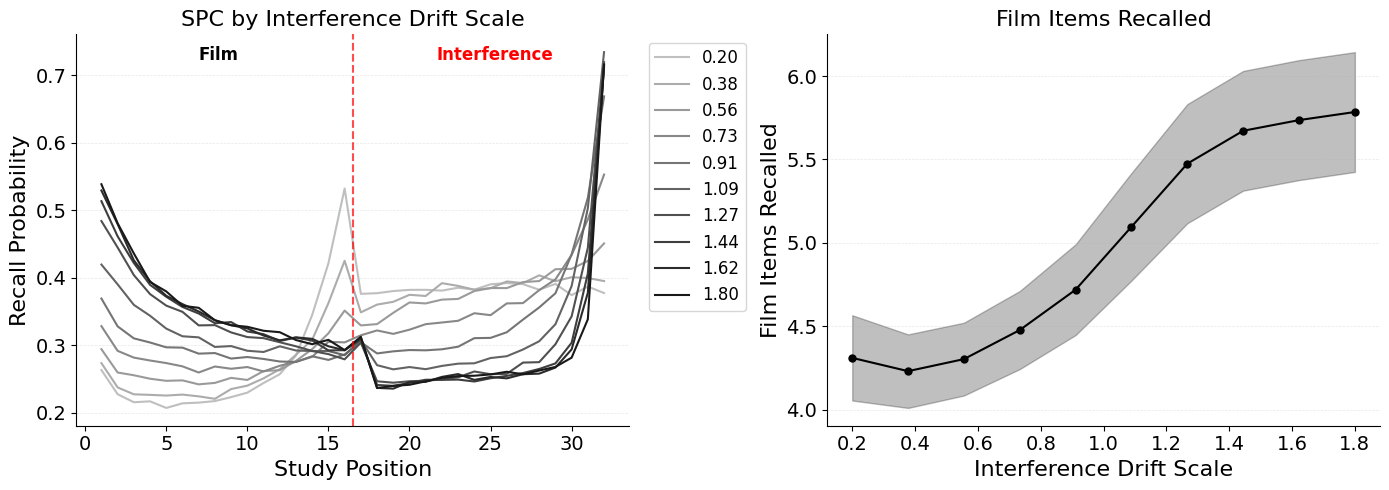

In [14]:
labels = [f"{v:.2f}" for v in drift_scale_values]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_interference_spc(sweep2_spcs, labels, N_FILM, ax=axes[0])
axes[0].set_title("SPC by Interference Drift Scale", fontsize=16)

means, ci_lo, ci_hi = zip(*sweep2_stats)
plot_summary_dv(
    drift_scale_values,
    means,
    ci_lo,
    ci_hi,
    xlabel="Interference Drift Scale",
    ax=axes[1],
)
axes[1].set_title("Film Items Recalled", fontsize=16)
if FILM_RECALLED_YLIM is not None:
    axes[1].set_ylim(*FILM_RECALLED_YLIM)

plt.tight_layout()
plt.show()

Low drift scales produce the most interference: competitors encoded in film-like context compete strongly at retrieval, suppressing film recall. As the scale increases, competitors are pushed into increasingly distant context states, reducing their activation during retrieval and allowing more film items to be recalled. The curve approaches a ceiling at high scales — beyond a certain point, further increases produce negligible additional relief because the competitors are already contextually irrelevant.

## Sweeping competitor count

The third intensifier is the sheer number of competitors. With drift and MCF scales both fixed at 1.0 (interference items encoded identically to additional study items), adding more competitors should reduce film recall — but with diminishing returns, because later competitors drift further from film context and therefore compete less effectively.

In [15]:
m_values = np.arange(10, 33, 2, dtype=int)
print(f"Competitor count sweep values: {m_values}")

sweep3_spcs = []
sweep3_stats = []

for m in m_values:
    sub_idx, rngs, rng = trial_indices_and_rngs(rng)
    interf_items = make_interference_items(int(m))
    recalls = batched_trial(
        sub_idx,
        rngs,
        params,
        FILM_ITEMS,
        interf_items,
        FILLER_ITEMS,
        jnp.float32(1.0),
        jnp.float32(1.0),
        jnp.float32(DEFAULT_REMINDER_DRIFT_SCALE),
        jnp.float32(DEFAULT_FILLER_DRIFT_SCALE),
        jnp.float32(DEFAULT_FILLER_MCF_SCALE),
    )
    sweep3_spcs.append(fixed_pres_spc(recalls, LIST_LENGTH))
    sweep3_stats.append(film_recalled_stats(recalls))

print("Sweep 3 done")

Competitor count sweep values: [10 12 14 16 18 20 22 24 26 28 30 32]
Sweep 3 done


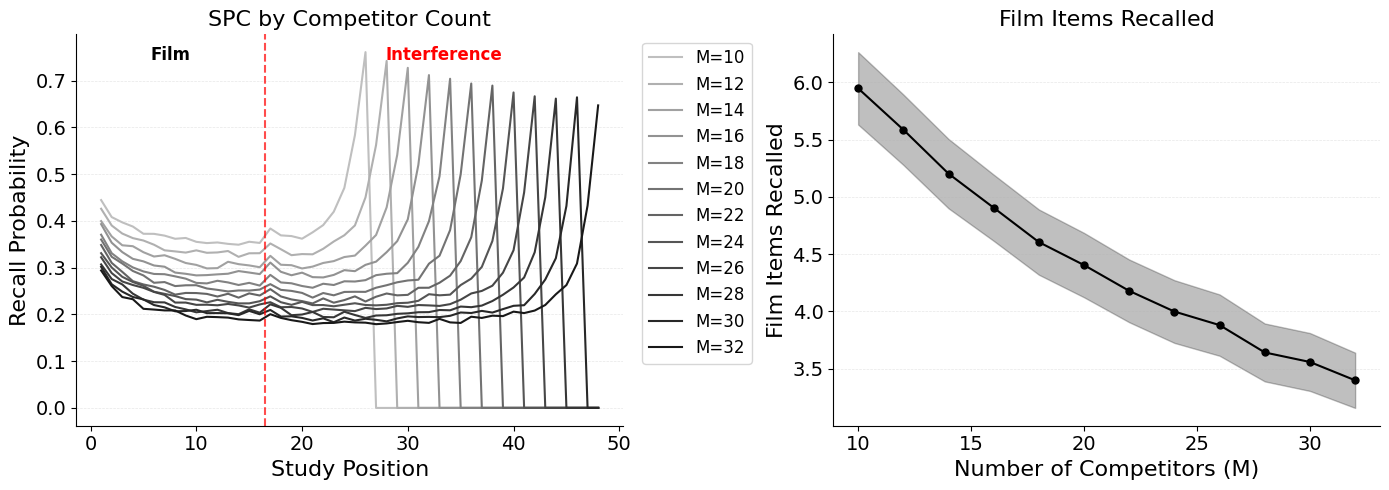

In [16]:
labels = [f"M={m}" for m in m_values]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_interference_spc(sweep3_spcs, labels, N_FILM, ax=axes[0])
axes[0].set_title("SPC by Competitor Count", fontsize=16)

means, ci_lo, ci_hi = zip(*sweep3_stats)
plot_summary_dv(
    m_values,
    means,
    ci_lo,
    ci_hi,
    xlabel="Number of Competitors (M)",
    ax=axes[1],
)
axes[1].set_title("Film Items Recalled", fontsize=16)
if FILM_RECALLED_YLIM is not None:
    axes[1].set_ylim(*FILM_RECALLED_YLIM)

plt.tight_layout()
plt.show()

More competitors produce more interference, but with diminishing returns as predicted. The first few competitors — those encoded in context most similar to the film items — have the strongest suppressive effect. Later competitors are encoded after more contextual drift and contribute progressively less interference. The SPC shows the interference effect concentrated at late film positions: recency is eroded first, while primacy is relatively protected by the strong M\_CF encoding at early positions.

This diminishing-returns pattern has an important empirical implication: the *timing* of interference (context proximity) matters more than the *amount* (raw count). A small number of competitors encoded in highly similar context can produce more interference than many competitors encoded after substantial drift.

## Summary and parameters for subsequent simulations

Three manipulations intensify interference from competing events, each operating through a distinct mechanism in the retrieved-context framework:

1. **MCF encoding strength** increases retrieval support for competitors, redistributing probability mass away from film items under the Luce choice rule. The effect is monotonic: stronger encoding produces more competition. The MCF scale multiplies the primacy gradient at each interference position, making the manipulation relative to each subject's fitted encoding parameters.

2. **Context proximity** (drift scale) controls how much context drifts during the interference phase relative to the film phase. Low scales keep competitors in context states that overlap with the film region; high scales push them into contextually distant states. The effect follows a dose-response curve with a ceiling.

3. **Competitor count** adds more entries into the association matrices, but with diminishing returns: later competitors accumulate more contextual drift and therefore compete less effectively. The timing of interference matters more than the raw amount.

The reminder drift scale controls how strongly film context is reinstated before interference begins — a scale factor applied to each subject's fitted `encoding_drift_rate`.

Default values for non-swept variables: interference MCF scale = 1.0, interference drift scale = 1.0, reminder drift scale = 1.0, competitor count = 16, filler drift scale = 1.0, filler MCF scale = 1.0. Filler parameters are held constant across all conditions.

In [17]:
print("Default parameters (non-swept variables):")
print("  Interference MCF scale:   1.0")
print("  Interference drift scale: 1.0")
print(f"  Reminder drift scale:     {DEFAULT_REMINDER_DRIFT_SCALE}")
print("  Filler drift scale:       1.0")
print("  Filler MCF scale:         1.0")
print(f"  Competitor count (M):     {M_DEFAULT}")
print(f"  Filler count:             {N_FILLER}")
print(f"  Max competitors (sweep):  {M_MAX}")
print(f"  Subjects:                 {n_subjects}")
print(f"  Replications per sweep:   {EXPERIMENT_COUNT}")

Default parameters (non-swept variables):
  Interference MCF scale:   1.0
  Interference drift scale: 1.0
  Reminder drift scale:     1.0
  Filler drift scale:       1.0
  Filler MCF scale:         1.0
  Competitor count (M):     16
  Filler count:             0
  Max competitors (sweep):  32
  Subjects:                 126
  Replications per sweep:   100
